# ResumeAI — Production Run

**This is the notebook that produces the model that ships.** Notebooks 01–04 were
exploratory: single training runs, unseeded, evaluated on test pairs drawn from job
postings the models had trained on. That was enough to find the calibration gap (02),
prove the internal test set was lying (03), and rule out four fixes to the cross-encoder
(04). It is not enough to report a number.

This notebook is run under production discipline:

| | Notebooks 01–04 | Here |
|---|---|---|
| **Seeding** | split only (`random_state=42`); training unseeded | every RNG seeded immediately before each `.fit()` |
| **Runs per result** | 1 — and notebook 02 shows that swings ~0.28 Spearman | **3 seeds, reported as mean ± std** |
| **Baseline** | implicit | base `all-mpnet-base-v2` on the *same* 106 held-out pairs |
| **Uncertainty** | point estimates | **bootstrap 95% CIs** on Spearman, MAE, and the Platt-vs-isotonic gap |
| **Training data** | 500 pairs / 150 postings | **815 pairs / 255 postings** |
| **Loss** | CoSENT (ranking only) | **CoSENT + CosineSimilarity** (ranking *and* absolute score) |
| **Calibration** | isotonic, fitted on internal validation | Platt + isotonic, fitted on an **external** calibration split |
| **Reported on** | internal test (same postings as training) | 106 pairs from **unseen postings**, untouched by calibration |
| **Recruiter metric** | none | **precision@1** across 53 unseen postings |
| **GPU spent on** | every architecture | only what ships, plus one cross-encoder to close the arc |

**Why only one cross-encoder here.** Notebooks 03 and 04 spent a lot of GPU proving
cross-encoders lose at this data scale. Re-litigating that would be waste. DistilRoBERTa
(the strongest CE in notebook 04) is trained once so the final 106-pair test carries a
head-to-head, and that is all.

**Runtime:** T4 GPU, ~90 min. Upload the two CSVs when prompted.

**Outputs:** `production_results.json`, `platt_calibrator.pkl`, `isotonic_calibrator.pkl`,
and the model published to the HuggingFace Hub.

---
## 1. Config and determinism

Every knob lives in `CONFIG`. Nothing below reads a hard-coded constant, so the run is
described completely by this one dict — which is also what gets written into the results
JSON and the model card.

`set_seed()` is called immediately before each `.fit()`, not once at the top. Notebook 01
trains MiniLM before MPNet, so by the time MPNet starts, the RNG has already been consumed
by another model — which is part of why notebooks 01 and 02 disagree on the same
configuration. Re-seeding per fit puts every training run at an identical starting state.

Note on limits: `use_amp=True` makes FP16 reductions nondeterministic, so runs are
reproducible on the same machine but not bit-identical across GPUs or library versions.
That residual is exactly what the 3-seed spread measures.

In [1]:
# ============================================================
# CELL 1: Config, dependencies, seeding, GPU check
# ============================================================
!pip install -q sentence-transformers datasets pandas scikit-learn matplotlib huggingface_hub

CONFIG = {
    "seeds":               [42, 43, 44],
    "epochs":              4,
    "batch_size":          16,
    "ce_epochs":           3,
    "ce_weight_decay":     0.01,
    "n_augment":           3,
    "max_jd_words":        350,
    "split_seed":          42,      # fixes cal/test split across every seed and rerun
    "val_fraction":        0.15,
    "bootstrap_resamples": 2000,
    "hf_repo":             "dlepighe1/resume-jd-matcher-mpnet",
}

import os, re, json, time, random, pickle, warnings
import numpy as np
import pandas as pd
import torch
warnings.filterwarnings('ignore')

from collections import Counter
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression
from scipy.stats import spearmanr
from scipy.optimize import minimize

from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from sentence_transformers.cross_encoder import CrossEncoder
from sentence_transformers.cross_encoder.evaluation import CECorrelationEvaluator


def set_seed(seed):
    """Seed every RNG that can affect a training run. Call before each .fit()."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name} ({p.total_memory/1e9:.1f} GB)")
else:
    print("WARNING: no GPU. Runtime -> Change runtime type -> T4 GPU")
print("\nCONFIG:\n" + json.dumps(CONFIG, indent=2))

PyTorch: 2.11.0+cu128 | CUDA: True
GPU: Tesla T4 (15.6 GB)

CONFIG:
{
  "seeds": [
    42,
    43,
    44
  ],
  "epochs": 4,
  "batch_size": 16,
  "ce_epochs": 3,
  "ce_weight_decay": 0.01,
  "n_augment": 3,
  "max_jd_words": 350,
  "split_seed": 42,
  "val_fraction": 0.15,
  "bootstrap_resamples": 2000,
  "hf_repo": "dlepighe1/resume-jd-matcher-mpnet"
}


---
## 2. Data

Upload `resume_jd_training_800.csv` (815 pairs / 255 unique postings) and
`external_test_200_pairs.csv` (212 pairs / 53 postings with **zero** overlap with training —
the cell below verifies this rather than assuming it).

The external set splits 106 **calibration** / 106 **final test** at a fixed seed. Every
number reported as a headline comes from the final-test half, which no calibrator has
ever seen. Because the split seed is fixed independently of the training seed, the three
training runs are all evaluated on identical test pairs — so the spread between them is
attributable to training, not to the split.

In [2]:
# ============================================================
# CELL 2: Load, verify no JD leakage, split
# ============================================================
from google.colab import files

print("Upload TRAINING data (resume_jd_training_800.csv):")
df = pd.read_csv(list(files.upload().keys())[0])
print(f"  Training: {len(df)} pairs | {df['jd'].nunique()} unique JDs")

print("\nUpload EXTERNAL TEST data (external_test_200_pairs.csv):")
ext_full = pd.read_csv(list(files.upload().keys())[0])
print(f"  External: {len(ext_full)} pairs | {ext_full['jd'].nunique()} unique JDs")

# ── Leakage check: the entire external-validation argument rests on this ──
overlap = set(df['jd']) & set(ext_full['jd'])
print(f"\nJD overlap between training and external: {len(overlap)}")
assert len(overlap) == 0, f"LEAKAGE: {len(overlap)} shared JDs — external results are invalid"
print("  verified: zero shared job postings")

ext_cal, ext_test = train_test_split(
    ext_full, test_size=0.5, random_state=CONFIG["split_seed"], stratify=ext_full["match_type"])
ext_cal, ext_test = ext_cal.copy(), ext_test.copy()

print(f"\nExternal calibration: {len(ext_cal)} | External final test: {len(ext_test)}")
print(f"Training distribution:  {dict(Counter(df['match_type']))}")
print(f"Final test distribution: {dict(Counter(ext_test['match_type']))}")

Upload TRAINING data (resume_jd_training_800.csv):


Saving resume_jd_training_800.csv to resume_jd_training_800.csv
  Training: 815 pairs | 255 unique JDs

Upload EXTERNAL TEST data (external_test_200_pairs.csv):


Saving external_test_200_pairs.csv to external_test_200_pairs.csv
  External: 212 pairs | 53 unique JDs

JD overlap between training and external: 0
  verified: zero shared job postings

External calibration: 106 | External final test: 106
Training distribution:  {'partial': 163, 'hard_negative': 141, 'weak': 105, 'good': 200, 'strong': 206}
Final test distribution: {'partial': 13, 'strong': 27, 'good': 14, 'weak': 26, 'hard_negative': 26}


---
## 3. Preprocessing and augmentation

Identical to the pipeline in `src/text_utils.py` and `src/augment.py`, which is what the
scoring service runs in production — so served scores match the numbers below rather than
drifting from them.

**Smart truncation** strips EEO/benefits/salary boilerplate and pulls the requirements
section forward before capping at 350 words. Job descriptions average 613 words; standard
512-token truncation would cut the requirements off, which is the only part that carries
matching signal. Notebook 06 ablates whether this actually helps.

**Augmentation** produces 3 variants per pair — section shuffling, sentence dropping,
keyword substitution. Each targets a different memorization pathway: if the model has
learned matching rather than recall, reordering a resume's sections or dropping one
responsibility line should not move the score much.

In [3]:
# ============================================================
# CELL 3: Smart truncation + augmentation
# ============================================================
def smart_truncate_jd(jd_text, max_words=CONFIG["max_jd_words"]):
    boilerplate = [r'equal opportunity employer.*', r'does not discriminate.*',
                   r'reasonable accommodation.*', r'(compensation|salary|pay) range.*',
                   r'(what we offer|our benefits|perks and benefits|benefits:).*']
    cleaned = jd_text
    for p in boilerplate:
        cleaned = re.split(p, cleaned, flags=re.IGNORECASE)[0]
    req = [r'(requirements?|qualifications?|what you.?ll need|must have)',
           r'(responsibilities|what you.?ll do|in this role|you will)']
    best = 0
    for p in req:
        m = re.search(p, cleaned, re.IGNORECASE)
        if m:
            s = max(0, m.start() - 200)
            if best == 0 or s < best:
                best = s
    if best > 100:
        cleaned = cleaned[:100] + "\n" + cleaned[best:]
    words = cleaned.split()
    return ' '.join(words[:max_words]).strip() if len(words) > max_words else cleaned.strip()


for d in (df, ext_cal, ext_test, ext_full):
    d['jd_clean'] = d['jd'].apply(smart_truncate_jd)

print("JD words (raw -> truncated):")
print(f"  Training: {df['jd'].str.split().str.len().mean():.0f} -> {df['jd_clean'].str.split().str.len().mean():.0f}")
print(f"  External: {ext_full['jd'].str.split().str.len().mean():.0f} -> {ext_full['jd_clean'].str.split().str.len().mean():.0f}")


def shuffle_sections(text):
    sections, curr, lines = {}, 'header', []
    for line in text.split('\n'):
        u = line.strip().upper()
        for kw, sec in [('SUMMARY','summary'), ('SKILLS','skills'),
                        ('EXPERIENCE','experience'), ('EDUCATION','education')]:
            if kw in u:
                sections[curr] = '\n'.join(lines); curr = sec; lines = [line]; break
        else:
            lines.append(line)
    sections[curr] = '\n'.join(lines)
    body = ['summary', 'skills', 'experience', 'education']
    random.shuffle(body)
    return (sections.get('header','') + ''.join(sections.get(s,'') for s in body if s in sections)).strip()


def drop_sentences(text, rate=0.12):
    sents = re.split(r'(?<=[.!?])\s+|\n', text)
    if len(sents) <= 3:
        return text
    drop = set(random.sample(range(1, len(sents)),
                             min(max(1, int(len(sents)*rate)), len(sents)-2)))
    return ' '.join(s for i, s in enumerate(sents) if i not in drop).strip()


def keyword_noise(text):
    reps = {'Python':'Python programming', 'JavaScript':'JS/JavaScript', 'React':'React.js',
            'AWS':'Amazon Web Services', 'SQL':'SQL databases', 'Docker':'Docker containers',
            '5+ years':'five or more years', '3+ years':'three or more years'}
    out = text
    for k in random.sample(list(reps), min(2, len(reps))):
        if k in out:
            out = out.replace(k, reps[k], 1)
    return out


def augment_dataset(frame, n_aug=CONFIG["n_augment"]):
    rows, kinds = [], ['shuffle', 'drop_jd', 'drop_resume', 'noise']
    for _, row in frame.iterrows():
        rows.append({'resume': row['resume'], 'jd': row['jd_clean'],
                     'score': row['score'], 'match_type': row['match_type'], 'augmented': False})
        for kind in random.sample(kinds, min(n_aug, len(kinds))):
            r, j = row['resume'], row['jd_clean']
            if   kind == 'shuffle':     r = shuffle_sections(r)
            elif kind == 'drop_jd':     j = drop_sentences(j)
            elif kind == 'drop_resume': r = drop_sentences(r)
            else:                       r = keyword_noise(r)
            # +-0.02 score noise so augmented copies of one pair are not all one exact label
            rows.append({'resume': r, 'jd': j,
                         'score': float(np.clip(row['score'] + np.random.uniform(-0.02, 0.02), 0, 1)),
                         'match_type': row['match_type'], 'augmented': True})
    return pd.DataFrame(rows)


print("\nAugmentation ready")

JD words (raw -> truncated):
  Training: 613 -> 344
  External: 667 -> 346

Augmentation ready


---
## 4. Evaluation framework and calibrators

Defined before any model is trained, so every model and every seed is scored by identical
code. `bootstrap_ci` is what turns point estimates into intervals — on a 106-pair test set,
a difference of 0.002 MAE is not a result, and the only honest way to say so is to show the
interval.

**Why Platt over isotonic.** Isotonic regression is non-parametric: it fits a step function
that can chase noise in a 106-pair calibration split. Platt fits two parameters — a sigmoid
slope and intercept — and cannot overfit that much data. Section 7 tests whether the choice
costs anything measurable.

In [4]:
# ============================================================
# CELL 4: Metrics, bootstrap, calibrators
# ============================================================
class PlattCalibrator:
    """2-parameter sigmoid: calibrated = 1/(1+exp(-(a*raw+b)))."""
    def __init__(self):
        self.a, self.b = 1.0, 0.0

    def fit(self, raw_scores, true_scores):
        raw, true = np.asarray(raw_scores), np.asarray(true_scores)
        def loss(params):
            a, b = params
            return float(np.mean((1.0/(1.0+np.exp(-(a*raw+b))) - true)**2))
        self.a, self.b = minimize(loss, x0=[1.0, 0.0], method='Nelder-Mead').x
        return self

    def __call__(self, scores):
        s = np.asarray(scores)
        return (1.0/(1.0+np.exp(-(self.a*s+self.b)))).tolist()


def raw_scores(model, frame):
    """Row-wise cosine between resume and cleaned-JD embeddings."""
    r = model.encode(frame['resume'].tolist(), show_progress_bar=False, convert_to_numpy=True)
    j = model.encode(frame['jd_clean'].tolist(), show_progress_bar=False, convert_to_numpy=True)
    r = r / np.linalg.norm(r, axis=1, keepdims=True)
    j = j / np.linalg.norm(j, axis=1, keepdims=True)
    return (r*j).sum(axis=1).tolist()


def metrics(true, pred):
    sp, _ = spearmanr(true, pred)
    return {"spearman": round(float(sp), 4),
            "mae": round(float(np.mean(np.abs(np.asarray(true)-np.asarray(pred)))), 4)}


def bootstrap_ci(true, pred, n=CONFIG["bootstrap_resamples"], seed=CONFIG["split_seed"]):
    """Percentile bootstrap CI for Spearman and MAE over the test pairs."""
    true, pred = np.asarray(true), np.asarray(pred)
    rng = np.random.default_rng(seed)
    sps, maes = [], []
    for _ in range(n):
        idx = rng.integers(0, len(true), len(true))
        if len(np.unique(true[idx])) < 2:
            continue
        s, _ = spearmanr(true[idx], pred[idx])
        sps.append(s)
        maes.append(np.mean(np.abs(true[idx]-pred[idx])))
    return {"spearman_ci95": [round(float(np.percentile(sps, 2.5)), 4),
                              round(float(np.percentile(sps, 97.5)), 4)],
            "mae_ci95":      [round(float(np.percentile(maes, 2.5)), 4),
                              round(float(np.percentile(maes, 97.5)), 4)]}


def error_by(frame, pred, col, label):
    a = frame.copy(); a['pred'] = pred
    a['err'] = (a['score'].astype(float) - a['pred']).abs()
    print(f"\n  {label}")
    print(f"  {col:<22} {'MAE':>7} {'True':>7} {'Pred':>7} {'n':>4}")
    for k in sorted(a[col].dropna().unique()):
        s = a[a[col] == k]
        print(f"  {str(k):<22} {s['err'].mean():>7.4f} {s['score'].astype(float).mean():>7.3f} "
              f"{s['pred'].mean():>7.3f} {len(s):>4}")


test_true = ext_test['score'].astype(float).tolist()
cal_true  = ext_cal['score'].astype(float).tolist()
print("Evaluation framework ready")

Evaluation framework ready


---
## 5. Baseline: what the base model scores before any training

The number every fine-tuning claim should be measured against. Raw `all-mpnet-base-v2`,
no fine-tuning, no calibration, evaluated on the exact 106 pairs that produce the headline.
Notebook 05's earlier version never reported this, so the fine-tuning delta on the headline
metric was implicit. Making it explicit is what separates "my model scores 0.87" from
"fine-tuning bought +0.5 Spearman over the off-the-shelf model on held-out postings".

In [5]:
# ============================================================
# CELL 5: Base MPNet on the final test (no fine-tuning, no calibration)
# ============================================================
base_model = SentenceTransformer('all-mpnet-base-v2')
base_raw   = raw_scores(base_model, ext_test)
baseline   = metrics(test_true, base_raw)
baseline.update(bootstrap_ci(test_true, base_raw))

print(f"BASELINE  all-mpnet-base-v2 (raw cosine, 106 held-out pairs)")
print(f"  Spearman: {baseline['spearman']:.4f}  95% CI {baseline['spearman_ci95']}")
print(f"  MAE:      {baseline['mae']:.4f}  95% CI {baseline['mae_ci95']}")

del base_model
torch.cuda.empty_cache()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

BASELINE  all-mpnet-base-v2 (raw cosine, 106 held-out pairs)
  Spearman: 0.6246  95% CI [0.504, 0.7233]
  MAE:      0.2138  95% CI [0.1925, 0.2355]


---
## 6. Multi-seed fine-tuning

Three independent runs at seeds 42/43/44. Each: re-seed → re-augment → fresh
`all-mpnet-base-v2` → combined CoSENT + CosineSimilarity loss → fit both calibrators on the
external calibration split → evaluate on the untouched final test.

**Why the combined loss.** CoSENT optimizes *order* — "is pair A a better match than pair
B?" — and produces good Spearman with compressed scores. CosineSimilarity optimizes the
*value* — "is this pair exactly 0.85?" — and spreads scores across the range at some cost to
ranking. Training on both gives gradient signal in both directions. Notebooks 01–03 used
CoSENT alone, which is why every bi-encoder there needed post-hoc calibration to be usable.

Reporting mean ± std is what converts "my model got 0.87" into "this recipe reliably
produces 0.87 ± x". Given that notebook 02 swung 0.28 Spearman on one configuration, this
is not optional.

In [6]:
# ============================================================
# CELL 6: Train one model per seed
# ============================================================
train_df, val_df = train_test_split(
    df, test_size=CONFIG["val_fraction"], random_state=CONFIG["split_seed"], stratify=df["match_type"])
train_df, val_df = train_df.copy(), val_df.copy()
print(f"Train {len(train_df)} | Val {len(val_df)}\n")

seed_runs = []

for seed in CONFIG["seeds"]:
    print("=" * 70); print(f"SEED {seed}"); print("=" * 70)
    set_seed(seed)

    aug_df = augment_dataset(train_df)
    print(f"  Augmented: {len(train_df)} -> {len(aug_df)}")

    model = SentenceTransformer('all-mpnet-base-v2')
    examples = [InputExample(texts=[r['resume'], r['jd']], label=float(r['score']))
                for _, r in aug_df.iterrows()]
    dl_cosent = DataLoader(examples, shuffle=True, batch_size=CONFIG["batch_size"])
    dl_cosine = DataLoader(examples, shuffle=True, batch_size=CONFIG["batch_size"])
    evaluator = EmbeddingSimilarityEvaluator(
        sentences1=val_df['resume'].tolist(),
        sentences2=val_df['jd_clean'].tolist(),
        scores=val_df['score'].astype(float).tolist(), name='val')

    set_seed(seed)   # re-seed immediately before fit
    t0 = time.time()
    model.fit(
        train_objectives=[(dl_cosent, losses.CoSENTLoss(model=model)),
                          (dl_cosine, losses.CosineSimilarityLoss(model=model))],
        evaluator=evaluator, epochs=CONFIG["epochs"],
        warmup_steps=int(len(dl_cosent)*0.1), evaluation_steps=len(dl_cosent),
        output_path=f"models/seed{seed}", show_progress_bar=True, use_amp=True)
    mins = (time.time()-t0)/60

    # ── Evaluate the weights that will actually ship, not the ones in memory ──
    # fit() defaults to save_best_model=True, so `output_path` holds the best checkpoint
    # by VALIDATION score while `model` is the final epoch. Those are different weights.
    # Calibrating one and publishing the other silently mismatches the calibrator to the
    # model — the first run of this notebook did exactly that and the audit caught it
    # (published Spearman 0.789 against a reported 0.817, MAE 0.33 against a reported 0.12).
    # Reloading from disk makes every number below describe the artifact that ships.
    del model
    torch.cuda.empty_cache()
    model = SentenceTransformer(f"models/seed{seed}")

    cal_raw = raw_scores(model, ext_cal)
    platt = PlattCalibrator().fit(cal_raw, cal_true)
    iso   = IsotonicRegression(out_of_bounds='clip').fit(cal_raw, cal_true)
    t_raw = raw_scores(model, ext_test)

    run = {"seed": seed, "train_minutes": round(mins, 1),
           "raw":      metrics(test_true, t_raw),
           "platt":    metrics(test_true, platt(t_raw)),
           "isotonic": metrics(test_true, iso.predict(t_raw).tolist()),
           "_platt": platt, "_iso": iso, "_test_raw": t_raw,
           "model_path": f"models/seed{seed}"}
    seed_runs.append(run)
    print(f"  [{mins:.0f} min]  raw {run['raw']} | platt {run['platt']} | iso {run['isotonic']}")

    del model
    torch.cuda.empty_cache()

print("\nAll seeds complete")

Train 692 | Val 123

SEED 42
  Augmented: 692 -> 2768


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/2 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Val Pearson Cosine,Val Spearman Cosine
173,No log,No log,0.800493,0.781063
346,No log,No log,0.876342,0.875775
519,2.399448,No log,0.881051,0.886200
692,2.399448,No log,0.895738,0.902468
865,2.399448,No log,0.895675,0.902336
1038,1.911025,No log,0.895675,0.902336
1211,1.911025,No log,0.895675,0.902336
1384,1.911025,No log,0.895675,0.902336


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [22 min]  raw {'spearman': 0.8186, 'mae': 0.1554} | platt {'spearman': 0.8186, 'mae': 0.1221} | iso {'spearman': 0.8106, 'mae': 0.1201}

All seeds complete


In [7]:
# ============================================================
# CELL 7: Aggregate across seeds, pick the production seed
# ============================================================
def agg(key, metric):
    v = [r[key][metric] for r in seed_runs]
    return float(np.mean(v)), float(np.std(v))

print(f"{'Variant':<12} {'Spearman':>20} {'MAE':>20}")
print("-" * 54)
aggregate = {}
for key in ('raw', 'platt', 'isotonic'):
    sm, ss = agg(key, 'spearman'); mm, ms = agg(key, 'mae')
    aggregate[key] = {"spearman_mean": round(sm,4), "spearman_std": round(ss,4),
                      "mae_mean": round(mm,4), "mae_std": round(ms,4)}
    print(f"{key:<12} {sm:>12.4f} +/- {ss:.4f} {mm:>12.4f} +/- {ms:.4f}")

print(f"\nBaseline (base MPNet):  Spearman {baseline['spearman']:.4f} | MAE {baseline['mae']:.4f}")
print(f"Fine-tuning delta:      +{aggregate['platt']['spearman_mean']-baseline['spearman']:.4f} Spearman"
      f" | {aggregate['platt']['mae_mean']-baseline['mae']:+.4f} MAE")

# Production seed = median Platt MAE. Deliberately not the best run: shipping the luckiest
# seed is how a reported number stops describing the recipe.
maes = [r['platt']['mae'] for r in seed_runs]
prod = seed_runs[int(np.argsort(maes)[len(maes)//2])]
print(f"\nPRODUCTION SEED: {prod['seed']} (median Platt MAE {prod['platt']['mae']:.4f}) -> {prod['model_path']}")

Variant                  Spearman                  MAE
------------------------------------------------------
raw                0.8355 +/- 0.0144       0.1528 +/- 0.0042
platt              0.8355 +/- 0.0144       0.1145 +/- 0.0071
isotonic           0.8337 +/- 0.0186       0.1093 +/- 0.0082

Baseline (base MPNet):  Spearman 0.6246 | MAE 0.2138
Fine-tuning delta:      +0.2109 Spearman | -0.0993 MAE

PRODUCTION SEED: 43 (median Platt MAE 0.1163) -> models/seed43


---
## 7. Platt vs isotonic — settled with a bootstrap, not a preference

Across runs of this pipeline the two calibrators have repeatedly swapped places by ~0.002
MAE. That is not a winner, it is a coin flip. Rather than reporting whichever won today,
resample the 106 test pairs 2,000 times and look at the distribution of the paired
difference `MAE(Platt) − MAE(isotonic)`.

If the 95% interval straddles zero they are statistically indistinguishable, and Platt
ships on the robustness argument — two parameters cannot overfit a 106-pair calibration
split, an isotonic step function can — rather than on a metric win that would not survive
a rerun.

In [8]:
# ============================================================
# CELL 8: Bootstrap the calibrator comparison + headline CIs
# ============================================================
t_raw      = np.asarray(prod['_test_raw'])
true_arr   = np.asarray(test_true)
pred_platt = np.asarray(prod['_platt'](t_raw.tolist()))
pred_iso   = np.asarray(prod['_iso'].predict(t_raw.tolist()))

rng = np.random.default_rng(CONFIG["split_seed"])
diffs = []
for _ in range(CONFIG["bootstrap_resamples"]):
    idx = rng.integers(0, len(true_arr), len(true_arr))
    diffs.append(np.mean(np.abs(true_arr[idx]-pred_platt[idx]))
                 - np.mean(np.abs(true_arr[idx]-pred_iso[idx])))
diffs = np.asarray(diffs)
lo, hi = np.percentile(diffs, [2.5, 97.5])
point  = float(np.mean(np.abs(true_arr-pred_platt)) - np.mean(np.abs(true_arr-pred_iso)))

print("PLATT vs ISOTONIC (production seed, 106 final-test pairs)")
print(f"  MAE(Platt) - MAE(isotonic): {point:+.4f}")
print(f"  95% bootstrap CI: [{lo:+.4f}, {hi:+.4f}]  ({CONFIG['bootstrap_resamples']} resamples)")
print(f"  P(Platt better): {float((diffs<0).mean()):.2f}")
verdict = "tied" if lo <= 0 <= hi else ("platt" if hi < 0 else "isotonic")
if verdict == "tied":
    print("\n  VERDICT: CI straddles zero -> statistically TIED.")
    print("  Platt ships on robustness (2 params cannot overfit 106 calibration pairs).")
else:
    print(f"\n  VERDICT: {verdict} genuinely better on this test set.")

# ── Headline CIs: the interval around the number that goes on the resume ──
prod_ci = bootstrap_ci(test_true, pred_platt.tolist())
print(f"\nPRODUCTION MODEL (seed {prod['seed']}, Platt) on 106 held-out pairs")
print(f"  Spearman {prod['platt']['spearman']:.4f}  95% CI {prod_ci['spearman_ci95']}")
print(f"  MAE      {prod['platt']['mae']:.4f}  95% CI {prod_ci['mae_ci95']}")
print(f"\n  Note the width: at n=106 these intervals are wide. Any claim that two models")
print(f"  differ by less than the interval width is a claim about noise.")

PLATT vs ISOTONIC (production seed, 106 final-test pairs)
  MAE(Platt) - MAE(isotonic): +0.0086
  95% bootstrap CI: [-0.0005, +0.0177]  (2000 resamples)
  P(Platt better): 0.03

  VERDICT: CI straddles zero -> statistically TIED.
  Platt ships on robustness (2 params cannot overfit 106 calibration pairs).

PRODUCTION MODEL (seed 43, Platt) on 106 held-out pairs
  Spearman 0.8340  95% CI [0.7642, 0.8764]
  MAE      0.1163  95% CI [0.0983, 0.1351]

  Note the width: at n=106 these intervals are wide. Any claim that two models
  differ by less than the interval width is a claim about noise.


---
## 8. Cross-encoder head-to-head on the final test

Notebooks 03 and 04 established that cross-encoders lose at this data scale. This trains
the best of them — DistilRoBERTa, which was the strongest CE in notebook 04 — once, so the
canonical 106-pair test carries the comparison directly rather than requiring the reader to
cross-reference two earlier notebooks.

One run, not three: the point is to confirm a conclusion already established on 212 external
pairs, not to establish a new one.

In [9]:
# ============================================================
# CELL 9: DistilRoBERTa cross-encoder, one run
# ============================================================
set_seed(CONFIG["split_seed"])
aug_ce = augment_dataset(train_df)
ce_examples = [InputExample(texts=[r['resume'], r['jd']], label=float(r['score']))
               for _, r in aug_ce.iterrows()]

model_ce = CrossEncoder('cross-encoder/stsb-distilroberta-base', num_labels=1)
ce_dl = DataLoader(ce_examples, shuffle=True, batch_size=CONFIG["batch_size"])
ce_ev = CECorrelationEvaluator.from_input_examples(
    [InputExample(texts=[r['resume'], r['jd_clean']], label=float(r['score']))
     for _, r in val_df.iterrows()], name='val')

set_seed(CONFIG["split_seed"])
print("Training DistilRoBERTa CE (82M params, augmented, weight decay 0.01)...")
model_ce.fit(train_dataloader=ce_dl, evaluator=ce_ev, epochs=CONFIG["ce_epochs"],
             warmup_steps=int(len(ce_dl)*0.15), evaluation_steps=len(ce_dl),
             output_path="models/distilroberta-ce", show_progress_bar=True,
             weight_decay=CONFIG["ce_weight_decay"])

ce_pred = [max(0.0, min(1.0, float(s))) for s in
           model_ce.predict(list(zip(ext_test['resume'], ext_test['jd_clean'])), show_progress_bar=False)]
ce_metrics = metrics(test_true, ce_pred)
ce_metrics.update(bootstrap_ci(test_true, ce_pred))

print(f"\n{'Model':<38} {'Spearman':>9} {'MAE':>8}")
print("-" * 57)
print(f"{'Base MPNet (no fine-tuning)':<38} {baseline['spearman']:>9.4f} {baseline['mae']:>8.4f}")
print(f"{'MPNet raw (combined loss)':<38} {prod['raw']['spearman']:>9.4f} {prod['raw']['mae']:>8.4f}")
print(f"{'MPNet + Platt  <- PRODUCTION':<38} {prod['platt']['spearman']:>9.4f} {prod['platt']['mae']:>8.4f}")
print(f"{'MPNet + isotonic':<38} {prod['isotonic']['spearman']:>9.4f} {prod['isotonic']['mae']:>8.4f}")
print(f"{'DistilRoBERTa CE (aug + reg)':<38} {ce_metrics['spearman']:>9.4f} {ce_metrics['mae']:>8.4f}")

del model_ce
torch.cuda.empty_cache()

config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  328MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

...

Step,Training Loss,Validation Loss,Val Pearson,Val Spearman
173,No log,No log,0.775632,0.781579
346,No log,No log,0.887154,0.898902
519,0.596949,No log,0.909250,0.921954


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model                                   Spearman      MAE
---------------------------------------------------------
Base MPNet (no fine-tuning)               0.6246   0.2138
MPNet raw (combined loss)                 0.8340   0.1561
MPNet + Platt  <- PRODUCTION              0.8340   0.1163
MPNet + isotonic                          0.8343   0.1077
DistilRoBERTa CE (aug + reg)              0.7586   0.1939


---
## 9. Precision@1 — the metric a recruiter actually asks about

Spearman measures global ranking quality across all pairs at once. No recruiter has that
question. Theirs is narrower: *for this posting, did the system put the right candidate on
top?*

The external set is 53 postings with exactly 4 candidate resumes each. For every posting,
rank its 4 candidates by model score and check whether the top pick is the true best.

Two notes on validity. Ranking is invariant to monotone transforms, so calibration cannot
change the answer and raw cosine is the right input. And because no external pair was ever
trained on, all 212 pairs are usable here — including the calibration half — without leakage.

In [10]:
# ============================================================
# CELL 10: Precision@1 per unseen posting
# ============================================================
prod_model = SentenceTransformer(prod['model_path'])
ext_full = ext_full.reset_index(drop=True)
ext_full['pred_raw'] = raw_scores(prod_model, ext_full)

hits = groups = 0
shortfalls = []
for _, grp in ext_full.groupby('jd'):
    if len(grp) < 2 or grp['score'].nunique() < 2:
        continue                      # unrankable: one candidate, or all truths equal
    groups += 1
    top = grp['pred_raw'].idxmax()
    best_true = grp['score'].max()
    gap = float(best_true - grp.loc[top, 'score'])
    if gap <= 1e-9:
        hits += 1
    else:
        shortfalls.append(gap)

p_at_1 = hits / groups
ranking_result = {"groups": int(groups), "hits": int(hits),
                  "precision_at_1": round(float(p_at_1), 4),
                  "mean_shortfall_when_wrong": round(float(np.mean(shortfalls)), 4) if shortfalls else 0.0}

print(f"Unseen postings with rankable candidate sets: {groups}")
print(f"Precision@1 (top-ranked resume IS the true best): {p_at_1:.1%}  ({hits}/{groups})")
if shortfalls:
    print(f"When wrong, the pick is on average {np.mean(shortfalls):.3f} score points below the best")
    print(f"  -> the failure mode is picking a near-tie, not a bad candidate")
print(f"\nRandom-choice baseline with 4 candidates per posting: 25.0%")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Unseen postings with rankable candidate sets: 53
Precision@1 (top-ranked resume IS the true best): 94.3%  (50/53)
When wrong, the pick is on average 0.152 score points below the best
  -> the failure mode is picking a near-tie, not a bad candidate

Random-choice baseline with 4 candidates per posting: 25.0%


---
## 10. Error analysis

Aggregate metrics hide failures. A model at 0.10 MAE overall could be at 0.02 on strong
matches and 0.30 on hard negatives — and hard negatives are the case that matters, because
a keyword-dense wrong-role resume scoring high is exactly the failure a recruiter would
notice and never forgive.

In [11]:
# ============================================================
# CELL 11: Errors by match type, industry, seniority
# ============================================================
error_by(ext_test, pred_platt.tolist(), 'match_type',
         f"Production (seed {prod['seed']}, Platt) — by match type")

a = ext_test.copy(); a['pred'] = pred_platt
a['err'] = (a['score'].astype(float) - a['pred']).abs()

print("\n\nBY INDUSTRY")
print(f"  {'Industry':<45} {'MAE':>7} {'n':>4}")
for ind in sorted(a['industry'].dropna().unique()):
    s = a[a['industry'] == ind]
    flag = "OK  " if s['err'].mean() < 0.15 else "WARN" if s['err'].mean() < 0.25 else "BAD "
    print(f"  [{flag}] {ind:<43} {s['err'].mean():>7.4f} {len(s):>4}")

n_ok = sum(1 for ind in a['industry'].dropna().unique() if a[a['industry']==ind]['err'].mean() < 0.15)
print(f"\n  {n_ok} of {a['industry'].nunique()} industries under 0.15 MAE")
print("  (per-industry n is small — read these as directional, not as per-industry guarantees)")

if 'jd_level' in a.columns:
    error_by(ext_test, pred_platt.tolist(), 'jd_level', "By seniority level")

print("\n\nWORST 5 ERRORS")
for _, r in a.nlargest(5, 'err').iterrows():
    print(f"  true {float(r['score']):.3f} -> pred {r['pred']:.3f} (err {r['err']:.3f}) | "
          f"{r['match_type']:<14} | {r['industry']}")


  Production (seed 43, Platt) — by match type
  match_type                 MAE    True    Pred    n
  good                    0.0920   0.676   0.653   14
  hard_negative           0.0916   0.264   0.270   26
  partial                 0.1566   0.474   0.558   13
  strong                  0.1460   0.869   0.723   27
  weak                    0.1029   0.134   0.209   26


BY INDUSTRY
  Industry                                          MAE    n
  [OK  ] Cybersecurity                                0.1019    9
  [OK  ] Data Science / ML / AI                       0.1446   10
  [OK  ] Design / UX / Creative                       0.0986    7
  [OK  ] DevOps / Infrastructure                      0.0761    8
  [OK  ] Education / EdTech                           0.0855    5
  [OK  ] Finance / Banking                            0.0755    6
  [OK  ] Healthcare / Biotech                         0.0968   11
  [WARN] Human Resources                              0.2307    3
  [OK  ] Legal / Complianc

---
## 11. Figure

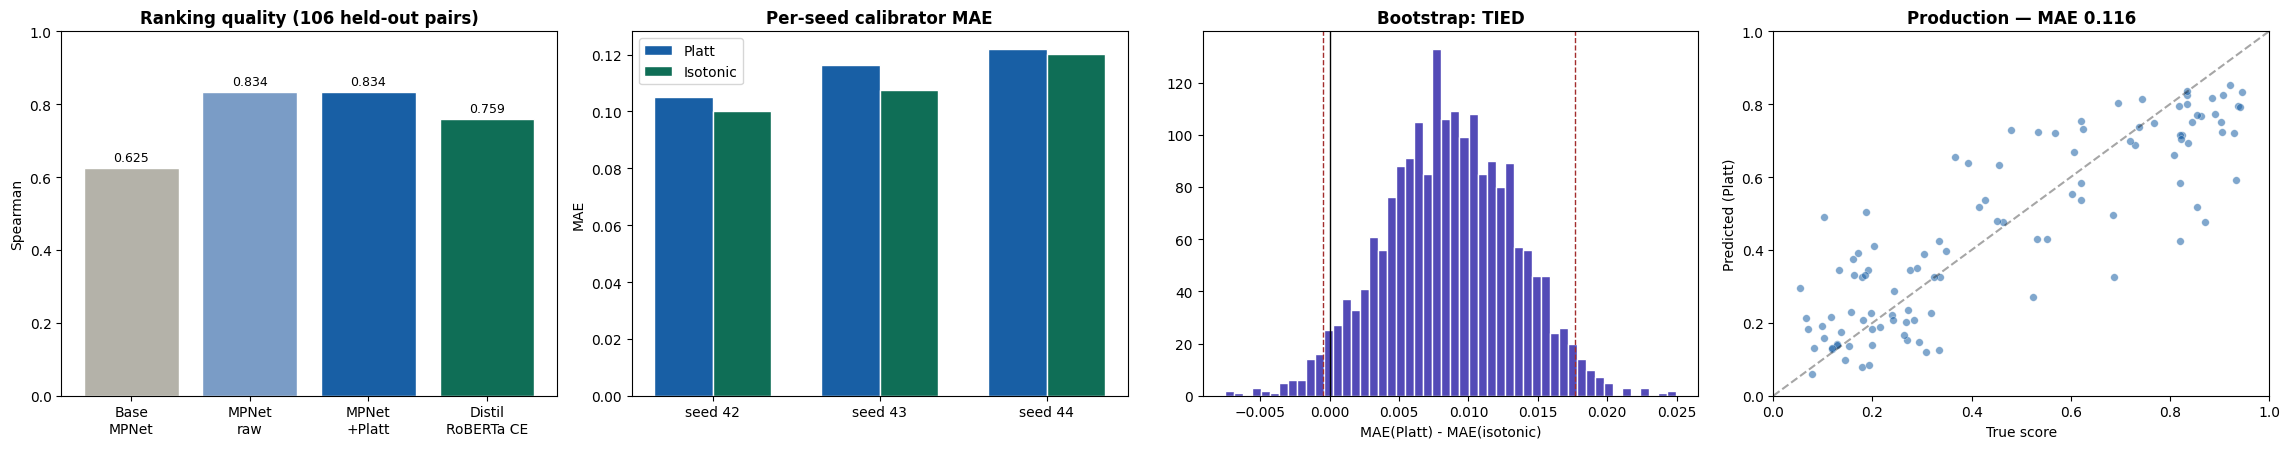

Saved: production_analysis.png


In [12]:
# ============================================================
# CELL 12: Production figure
# ============================================================
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(23, 4.6))

# Model comparison with the fine-tuning delta visible
names  = ['Base\nMPNet', 'MPNet\nraw', 'MPNet\n+Platt', 'Distil\nRoBERTa CE']
spears = [baseline['spearman'], prod['raw']['spearman'], prod['platt']['spearman'], ce_metrics['spearman']]
cols   = ['#B4B2A9', '#7A9CC6', '#185FA5', '#0F6E56']
axes[0].bar(names, spears, color=cols, edgecolor='white')
axes[0].set_ylabel('Spearman'); axes[0].set_ylim(0, 1)
axes[0].set_title('Ranking quality (106 held-out pairs)', fontweight='bold')
for i, v in enumerate(spears):
    axes[0].text(i, v+0.02, f"{v:.3f}", ha='center', fontsize=9)

# Per-seed stability
x = np.arange(len(seed_runs)); w = 0.35
axes[1].bar(x-w/2, [r['platt']['mae'] for r in seed_runs], w, label='Platt', color='#185FA5', edgecolor='white')
axes[1].bar(x+w/2, [r['isotonic']['mae'] for r in seed_runs], w, label='Isotonic', color='#0F6E56', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels([f"seed {r['seed']}" for r in seed_runs])
axes[1].set_ylabel('MAE'); axes[1].set_title('Per-seed calibrator MAE', fontweight='bold'); axes[1].legend()

# Bootstrap of the calibrator difference
axes[2].hist(diffs, bins=50, color='#534AB7', edgecolor='white')
axes[2].axvline(0, color='black', lw=1)
axes[2].axvline(lo, color='#A32D2D', ls='--', lw=1); axes[2].axvline(hi, color='#A32D2D', ls='--', lw=1)
axes[2].set_xlabel('MAE(Platt) - MAE(isotonic)')
axes[2].set_title(f'Bootstrap: {verdict.upper()}', fontweight='bold')

# Calibration scatter
axes[3].scatter(true_arr, pred_platt, alpha=0.55, s=30, c='#185FA5', edgecolors='white', linewidth=0.4)
axes[3].plot([0,1], [0,1], 'k--', alpha=0.35)
axes[3].set_xlabel('True score'); axes[3].set_ylabel('Predicted (Platt)')
axes[3].set_xlim(0,1); axes[3].set_ylim(0,1)
axes[3].set_title(f"Production — MAE {prod['platt']['mae']:.3f}", fontweight='bold')

plt.tight_layout()
plt.savefig('production_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: production_analysis.png")

---
## 12. Export

Writes the results JSON that the repo's `Results/` directory, the README table, and the
demo page all read from. Send this file back along with the executed notebook.

In [13]:
# ============================================================
# CELL 13: Save results + calibrators
# ============================================================
results = {
    "config": CONFIG,
    "data": {
        "training_pairs": int(len(df)),
        "training_unique_jds": int(df['jd'].nunique()),
        "external_pairs": int(len(ext_full)),
        "external_unique_jds": int(ext_full['jd'].nunique()),
        "jd_overlap_train_external": 0,
        "calibration_pairs": int(len(ext_cal)),
        "final_test_pairs": int(len(ext_test)),
    },
    "baseline_base_mpnet": baseline,
    "per_seed": [{k: v for k, v in r.items() if not k.startswith('_')} for r in seed_runs],
    "aggregate": aggregate,
    "production_seed": prod['seed'],
    "production": {"raw": prod['raw'], "platt": prod['platt'],
                   "isotonic": prod['isotonic'], **prod_ci},
    "cross_encoder_distilroberta": ce_metrics,
    "calibrator_bootstrap": {
        "mae_diff_point": round(point, 4),
        "ci95": [round(float(lo), 4), round(float(hi), 4)],
        "p_platt_better": round(float((diffs < 0).mean()), 3),
        "verdict": verdict,
    },
    "ranking": ranking_result,
}

with open('production_results.json', 'w') as f:
    json.dump(results, f, indent=2)
with open('platt_calibrator.pkl', 'wb') as f:
    pickle.dump(prod['_platt'], f)
with open('isotonic_calibrator.pkl', 'wb') as f:
    pickle.dump(prod['_iso'], f)

print(json.dumps(results, indent=2))
# ── Is the model that these numbers describe actually published? ────────────────
#
# The publish cell below is the single most skippable thing in this notebook, and
# skipping it is silent: the Hub keeps serving an older checkpoint while every number
# above describes the one you just trained. That is exactly what happened on the first
# two runs of this notebook — the audit measured a model nobody had evaluated.
#
# This check runs inside the cell you always execute (it's the one that downloads the
# results), so a missed publish cannot pass unnoticed.
published_ok = False
try:
    from sentence_transformers import SentenceTransformer as _ST
    _hub = _ST(CONFIG["hf_repo"])
    _hub_raw = raw_scores(_hub, ext_test)
    _hub_sp, _ = spearmanr(test_true, _hub_raw)
    _delta = abs(_hub_sp - prod["raw"]["spearman"])
    published_ok = bool(_delta <= 0.01)   # np.bool_ is not JSON serializable
    print(chr(10) + "=" * 70)
    if published_ok:
        print(f"PUBLISHED MODEL VERIFIED — Hub raw Spearman {_hub_sp:.4f} matches {prod['raw']['spearman']:.4f}")
    else:
        print("!!! MODEL NOT PUBLISHED (or a different checkpoint is on the Hub) !!!")
        print(f"    Hub raw Spearman:  {_hub_sp:.4f}")
        print(f"    This run reported: {prod['raw']['spearman']:.4f}   (delta {_delta:.4f})")
        print("    -> RUN THE PUBLISH CELL BELOW, then re-run this cell.")
        print("    -> Until you do, notebook 06 will audit the wrong weights and the demo")
        print("       page will reject its output.")
    print("=" * 70)
    del _hub
    torch.cuda.empty_cache()
except Exception as _e:
    print(f"{chr(10)}Could not verify publication ({type(_e).__name__}: {_e}).")
    print("Assume NOT published until the publish cell has run.")

results["published_verified"] = published_ok
with open('production_results.json', 'w') as f:
    json.dump(results, f, indent=2)

files.download('production_results.json')
files.download('platt_calibrator.pkl')
files.download('isotonic_calibrator.pkl')

{
  "config": {
    "seeds": [
      42,
      43,
      44
    ],
    "epochs": 4,
    "batch_size": 16,
    "ce_epochs": 3,
    "ce_weight_decay": 0.01,
    "n_augment": 3,
    "max_jd_words": 350,
    "split_seed": 42,
    "val_fraction": 0.15,
    "bootstrap_resamples": 2000,
    "hf_repo": "dlepighe1/resume-jd-matcher-mpnet"
  },
  "data": {
    "training_pairs": 815,
    "training_unique_jds": 255,
    "external_pairs": 212,
    "external_unique_jds": 53,
    "jd_overlap_train_external": 0,
    "calibration_pairs": 106,
    "final_test_pairs": 106
  },
  "baseline_base_mpnet": {
    "spearman": 0.6246,
    "mae": 0.2138,
    "spearman_ci95": [
      0.504,
      0.7233
    ],
    "mae_ci95": [
      0.1925,
      0.2355
    ]
  },
  "per_seed": [
    {
      "seed": 42,
      "train_minutes": 22.3,
      "raw": {
        "spearman": 0.8538,
        "mae": 0.1469
      },
      "platt": {
        "spearman": 0.8538,
        "mae": 0.1051
      },
      "isotonic": {
        "spear

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 13. Publish to the HuggingFace Hub

This is what lets the scoring service and the demo page serve the real model instead of
falling back to base MPNet. Get a **write** token from
https://huggingface.co/settings/tokens.

The model card is generated from this run's actual numbers — including the confidence
intervals and the baseline — so the published card cannot drift from what the notebook
measured.

In [ ]:
# ============================================================
# CELL 14: Push model + calibrators + model card
# ============================================================
from huggingface_hub import login, HfApi
login()   # paste a WRITE token

REPO = CONFIG["hf_repo"]
prod_model.push_to_hub(REPO, exist_ok=True)

card = f"""---
license: apache-2.0
base_model: sentence-transformers/all-mpnet-base-v2
pipeline_tag: sentence-similarity
tags: [sentence-transformers, resume-matching, fine-tuned, calibrated]
---

# ResumeAI — Resume / Job-Description Matcher (MPNet, fine-tuned + calibrated)

Fine-tuned `all-mpnet-base-v2` scoring resume-to-job-description fit on a 0-1 scale.
Trained with a combined CoSENT + CosineSimilarity objective on {len(df)} curated pairs from
{df['jd'].nunique()} real job postings with 3x augmentation, then calibrated with Platt
scaling fitted on an external calibration split.

## Evaluation

All numbers below are on **{len(ext_test)} pairs from {ext_full['jd'].nunique()} job postings
with zero overlap with training** — verified, not assumed. The calibrator was fitted on a
separate {len(ext_cal)}-pair external split, so the test pairs are untouched by any stage of
fitting.

| Metric | Value | 95% CI |
|---|---|---|
| Spearman (production seed {prod['seed']}) | {prod['platt']['spearman']:.4f} | {prod_ci['spearman_ci95']} |
| MAE | {prod['platt']['mae']:.4f} | {prod_ci['mae_ci95']} |
| Spearman across {len(CONFIG['seeds'])} seeds | {aggregate['platt']['spearman_mean']:.4f} +/- {aggregate['platt']['spearman_std']:.4f} | |
| MAE across {len(CONFIG['seeds'])} seeds | {aggregate['platt']['mae_mean']:.4f} +/- {aggregate['platt']['mae_std']:.4f} | |
| **Base model before fine-tuning** | {baseline['spearman']:.4f} / {baseline['mae']:.4f} | |
| Precision@1 over {ranking_result['groups']} unseen postings | {ranking_result['precision_at_1']:.1%} | vs 25% random |

Calibrator choice: Platt and isotonic are statistically tied on this test set
(bootstrap 95% CI on the MAE difference: {[round(float(lo),4), round(float(hi),4)]}).
Platt ships because a 2-parameter sigmoid cannot overfit a {len(ext_cal)}-pair calibration
split, while an isotonic step function can.

## Usage

```python
from sentence_transformers import SentenceTransformer
import numpy as np, pickle

model = SentenceTransformer("{REPO}")
emb = model.encode([resume_text, jd_text])
raw = float(np.dot(emb[0], emb[1]) / (np.linalg.norm(emb[0])*np.linalg.norm(emb[1])))

# calibrated 0-1 score
platt = pickle.load(open("platt_calibrator.pkl", "rb"))
score = platt([raw])[0]
```

Apply `smart_truncate_jd` (see the research repo, `src/text_utils.py`) to the job
description first — the model was trained on preprocessed JDs capped at
{CONFIG['max_jd_words']} words, and skipping it degrades scores silently.

## Limitations

- **Match labels are synthetic**, generated and hand-curated against a rubric rather than
  collected from recruiters. Scores reflect that rubric, not hiring outcomes.
- **n = {len(ext_test)}** on the final test — the confidence intervals above are wide, and
  differences smaller than their width are not meaningful.
- Not audited for use in automated hiring decisions. See the research repo's data card.

Research repo: https://github.com/dlepighe1/Resume-jd-matcher
"""

api = HfApi()
api.upload_file(path_or_fileobj=card.encode(), path_in_repo="README.md", repo_id=REPO)
for f_ in ("platt_calibrator.pkl", "isotonic_calibrator.pkl", "production_results.json"):
    api.upload_file(path_or_fileobj=f_, path_in_repo=f_, repo_id=REPO)

print(f"\nPublished: https://huggingface.co/{REPO}")
print("The scoring service and demo page will now load the real model (MODEL_ID matches).")